In [1]:
import sys, os
sys.path.insert(0, '/local/data/public/skcb2/tddft/inq-stack/python')
import numpy as np
from IPython.display import Image, display
from inqview.visualisation import style
style.apply_theme()
SYS = '/local/data/public/skcb2/tddft/ResearchProject/systems/localised_jellium'
print('theme applied; provenance root:', SYS)

theme applied; provenance root: /local/data/public/skcb2/tddft/ResearchProject/systems/localised_jellium


# sigma1_masspair · `wp_m3_k4p5` — run notebook

**Config:** clean qsp_phase3 geometry (50×50×90, dx 0.5, N=82, two-sided CAP
η=−0.7 at ±35..±45, dt 0.04, 2500 steps → τ=100); WP density-width σ_ρ=1.0
Bohr (`sigma(√2)`, house label σ_WP≈1.41 — see plan "σ convention
correction"), k0=4.5, **m=3** (v=1.50, E=92 eV), launch z=−16.5
(4 Bohr from the slab face). Full ledger + per-step pairwise `interactions.csv`
+ checkpoints every 200 steps.

**Goal was a monotonic energy decay (as the σ=0.5/m=1 clean run). Headline:
the drain-then-rise artifact RETURNS in this clean geometry — see §2/§6.**

Plan: `docs/plans/sigma1-masspair-decay-runs.md` · Handover:
`docs/handovers/energy-oscillation-debugging.md`

## §1 — Run summary (verbatim `run_summary.txt`)

In [2]:
rows = []
for line in open('/local/data/public/skcb2/tddft/ResearchProject/systems/localised_jellium/scripts/sigma1_masspair/wp/results' + "/wp_m3_k4p5/run_summary.txt"):
    line = line.rstrip("\n")
    if not line.strip(): continue
    k, _, v = line.partition("=")
    rows.append((k.strip(), v.strip()))
from IPython.display import Markdown
Markdown("| key | value |\n|---|---|\n" + "\n".join(
    f"| {k} | {v.replace('|', chr(92)+'|')} |" for k, v in rows))

| key | value |
|---|---|
| run | localised_jellium/sigma1_masspair/wp_m3_k4p5 |
| engine | inq-study |
| projectile | wavepacket sigma 1.41421356237 k0 4.5  inverse_mass = 0.333333333333  m_eff = 3 |
| velocity_au | 1.5  E_eV = 91.83842775 |
| cap | on (two-sided sin2, eta -0.7 Ha, 10 Bohr/side, region +/-35..+/-45) |
| cell_bohr | 50x50x90  spacing = 0.5 |
| background | slab half_width 12.5 axis 2 |
| n_electrons | 82  n_states = 61  wp_state_index = 60 |
| wp_norm_after | 1  launch_z = -16.5 |
| start_step | 0  n_steps = 2500  dt_au = 0.04  write_every = 8  ckpt_every = 200 |
| gs_dir | /local/data/public/skcb2/tddft/ResearchProject/systems/localised_jellium/shared_gs/slab_n82_L50x50x90 |
| wall_time_s | 13026.6007728 |
| run_completed | true |

## §2 — Energy ledger

Left: ΔE_total(t). Right: the four ledger components (Δ from t=0). The
post-minimum rise lives entirely in `energy_kinetic`.

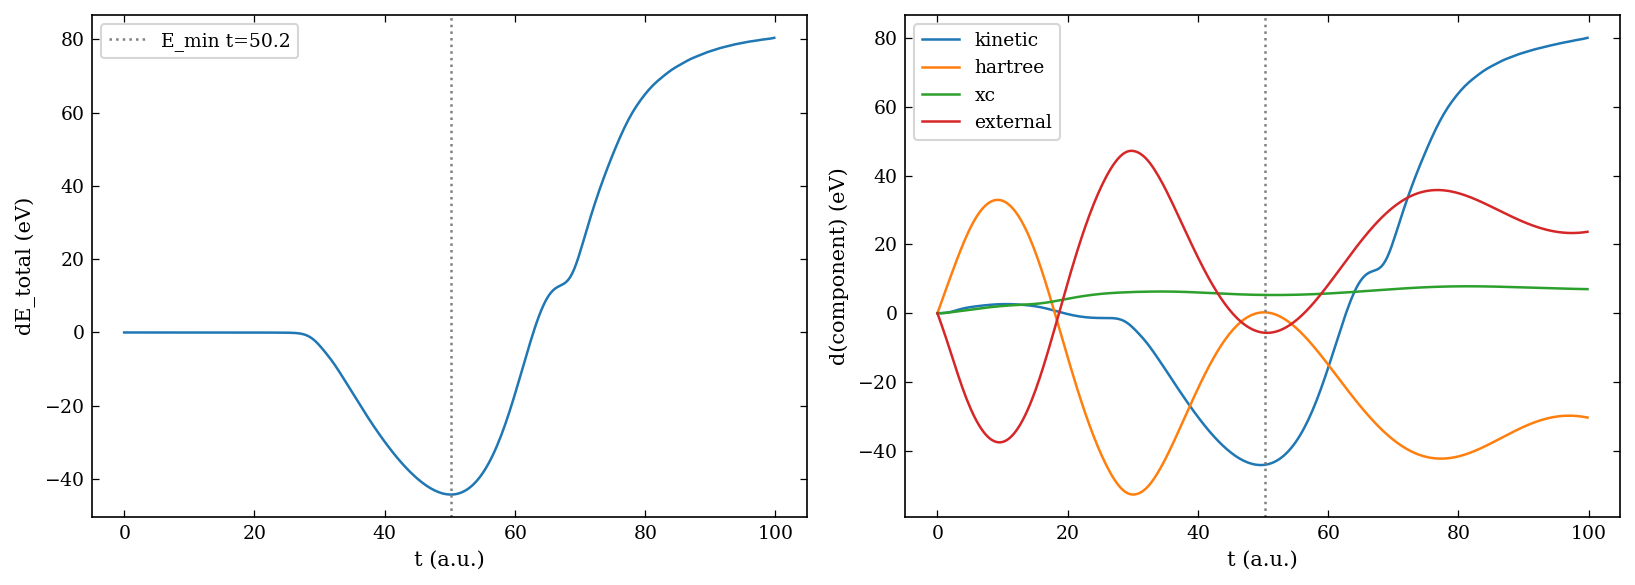

drain 44.2 eV   E_min at t=50.2   rise to tau +124.7 eV
d(kinetic) over the rise: +124.2 eV


In [3]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, os
HA = 27.211386
WPRES = '/local/data/public/skcb2/tddft/ResearchProject/systems/localised_jellium/scripts/sigma1_masspair/wp/results'
P3RES = '/local/data/public/skcb2/tddft/ResearchProject/systems/localised_jellium/scripts/qsp_phase3/wp/results/p3_wp_m1_rerun'
os.makedirs("figs", exist_ok=True)
def load(run):
    d = {}
    d["obs"] = pd.read_csv(f"{WPRES}/{run}/raw/observables/observables.csv")
    d["ix"]  = pd.read_csv(f"{WPRES}/{run}/raw/observables/interactions.csv")
    d["rs"]  = pd.read_csv(f"{WPRES}/{run}/raw/observables/wp_real_space_stats.csv", skiprows=1)
    d["ms"]  = pd.read_csv(f"{WPRES}/{run}/raw/observables/wp_momentum_stats.csv", skiprows=1)
    d["ne"]  = pd.read_csv(f"{WPRES}/{run}/raw/observables/electron_number.csv")
    d["se"]  = pd.read_csv(f"{WPRES}/{run}/raw/observables/state_energies.csv")
    return d
d = load('wp_m3_k4p5')
o = d["obs"]; t, E = o.time_au.values, o.energy_total.values
im = int(E.argmin())
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(t, (E-E[0])*HA)
ax[0].axvline(t[im], ls=":", color="0.5", label=f"E_min t={t[im]:.1f}")
ax[0].set_xlabel("t (a.u.)"); ax[0].set_ylabel("dE_total (eV)"); ax[0].legend()
for c in ("energy_kinetic","energy_hartree","energy_xc","energy_external"):
    ax[1].plot(t, (o[c]-o[c].iloc[0])*HA, label=c.replace("energy_",""))
ax[1].axvline(t[im], ls=":", color="0.5")
ax[1].set_xlabel("t (a.u.)"); ax[1].set_ylabel("d(component) (eV)"); ax[1].legend()
fig.tight_layout(); fig.savefig("figs/wp_m3_k4p5_ledger.png", dpi=150); plt.show()
print(f"drain {(E[0]-E[im])*HA:.1f} eV   E_min at t={t[im]:.1f}   "
      f"rise to tau {(E[-1]-E[im])*HA:+.1f} eV")
print(f"d(kinetic) over the rise: {(o.energy_kinetic.iloc[-1]-o.energy_kinetic.iloc[im])*HA:+.1f} eV")

## §3 — WP transport and spreading

σ_z(t) against free flight with the *measured* birth σ_pz; the slab face is
reached at t≈2.7. Free-flight prediction stops applying inside the
slab.

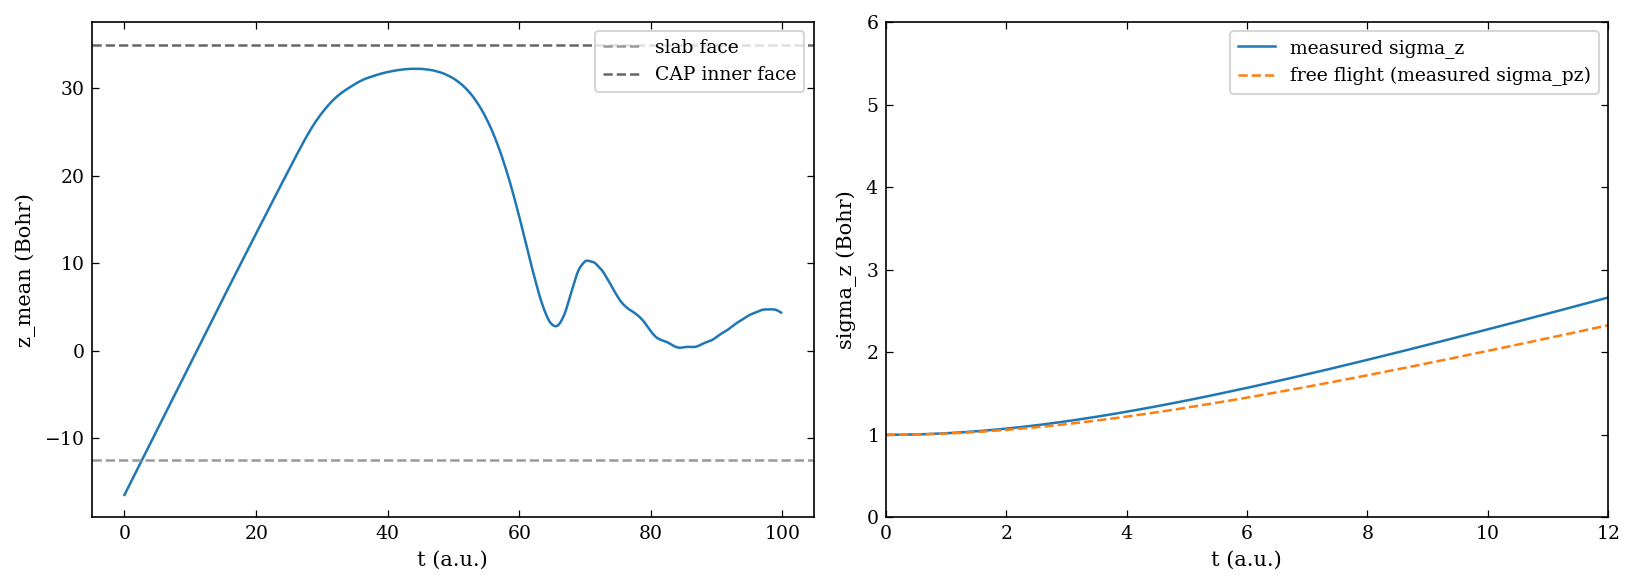

sigma_pz(0)=0.525 (min-unc 0.50)   spreading at face: 15.1%


In [4]:
rs, ms = d["rs"], d["ms"]
tr = rs.time_au.values
sz = np.sqrt(rs.z2_mean.values - rs.z_mean.values**2)
sp = float(np.sqrt(ms.sigma_pz2.iloc[0])); s0 = sz[0]
pred = np.sqrt(s0**2 + (sp*tr/3)**2)
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(tr, rs.z_mean.values); ax[0].axhline(-12.5, ls="--", color="0.6", label="slab face")
ax[0].axhline(35, ls="--", color="0.4", label="CAP inner face")
ax[0].set_xlabel("t (a.u.)"); ax[0].set_ylabel("z_mean (Bohr)"); ax[0].legend()
ax[1].plot(tr, sz, label="measured sigma_z")
ax[1].plot(tr, pred, "--", label="free flight (measured sigma_pz)")
ax[1].set_xlim(0, 12); ax[1].set_ylim(0, 6)
ax[1].set_xlabel("t (a.u.)"); ax[1].set_ylabel("sigma_z (Bohr)"); ax[1].legend()
fig.tight_layout(); fig.savefig("figs/wp_m3_k4p5_transport.png", dpi=150); plt.show()
zi = int(np.argmax(rs.z_mean.values >= -12.5))
print(f"sigma_pz(0)={sp:.3f} (min-unc 0.50)   spreading at face: {(sz[zi]/s0-1)*100:.1f}%")

## §4 — Absorption: N_total and the WP state norm

t_min coincides with the WP norm crossing ~5 % (the CAP has essentially
finished absorbing the packet); the kinetic rise happens as norm → 1e-4.

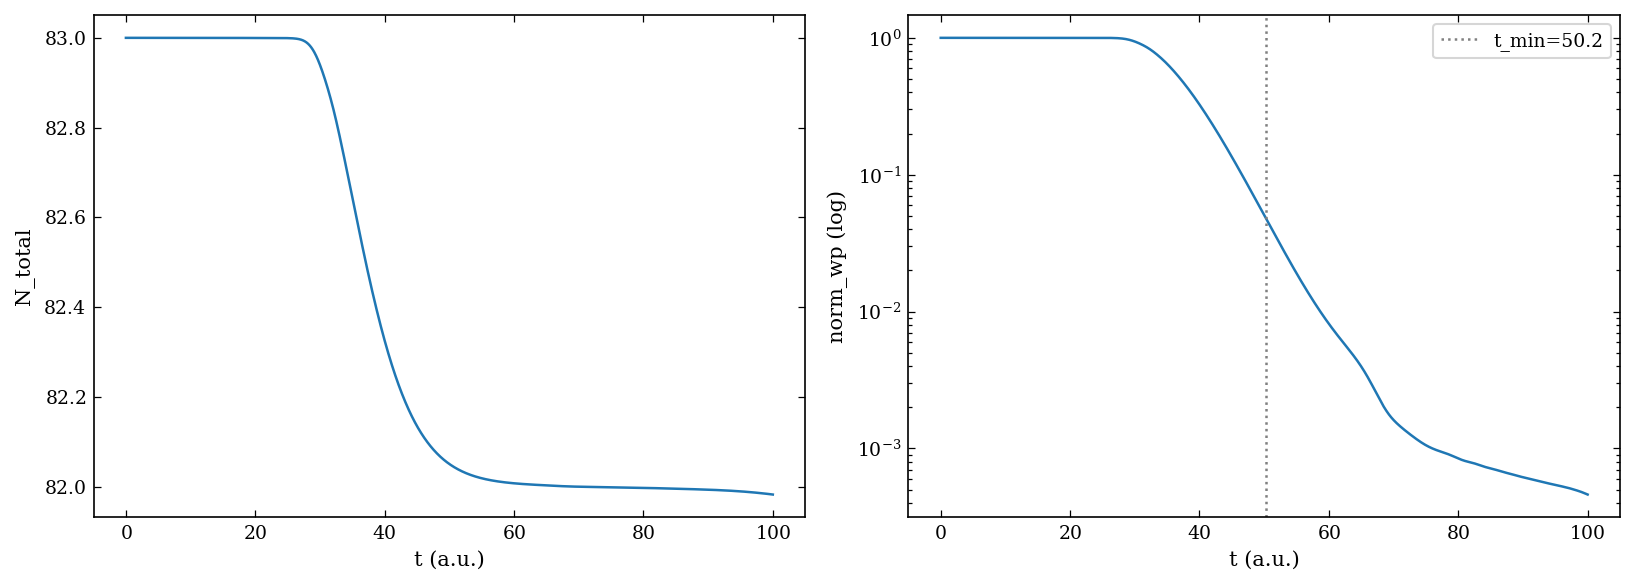

absorbed 1.018 e   norm_wp at t_min = 0.0483   at tau = 4.61e-04


In [5]:
ix, ne = d["ix"], d["ne"]
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(ne.time_au, ne.N_total); ax[0].set_xlabel("t (a.u.)"); ax[0].set_ylabel("N_total")
ax[1].semilogy(ix.time_au, ix.norm_wp)
ax[1].axvline(t[im], ls=":", color="0.5", label=f"t_min={t[im]:.1f}")
ax[1].set_xlabel("t (a.u.)"); ax[1].set_ylabel("norm_wp (log)"); ax[1].legend()
fig.tight_layout(); fig.savefig("figs/wp_m3_k4p5_absorption.png", dpi=150); plt.show()
j = int(np.searchsorted(ix.time_au.values, t[im]))
print(f"absorbed {ne.N_total.iloc[0]-ne.N_total.iloc[-1]:.3f} e   "
      f"norm_wp at t_min = {ix.norm_wp.iloc[j]:.4f}   at tau = {ix.norm_wp.iloc[-1]:.2e}")

## §5 — Pairwise Coulomb decomposition (P/S/B)

Every channel Δ from t=0, plus the closure residual against INQ's ledger
(must be ~1e-9). The Coulomb channels are QUIET through the rise — the
artifact is not electrostatic.

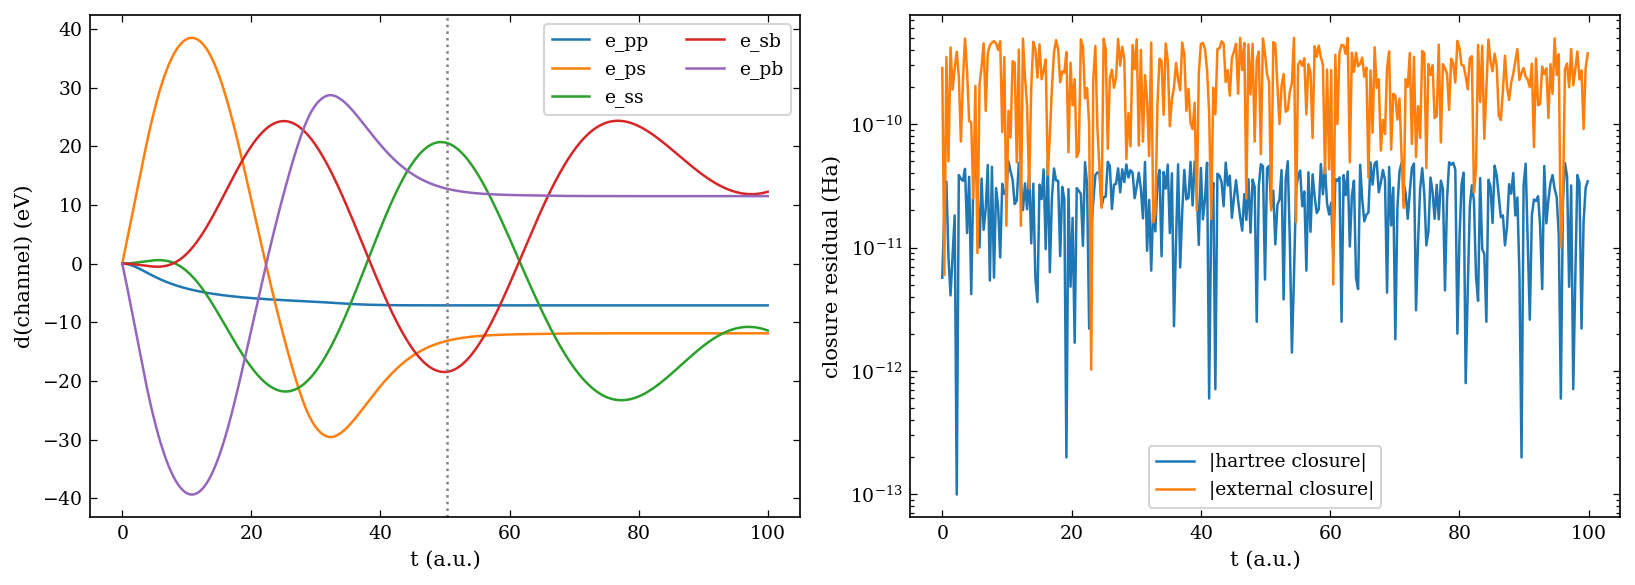

max closure: 5.0e-11 5.0e-10 Ha


In [6]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
for c in ("e_pp","e_ps","e_ss","e_sb","e_pb"):
    ax[0].plot(ix.time_au, (ix[c]-ix[c].iloc[0])*HA, label=c)
ax[0].axvline(t[im], ls=":", color="0.5")
ax[0].set_xlabel("t (a.u.)"); ax[0].set_ylabel("d(channel) (eV)"); ax[0].legend(ncol=2)
mrg = o.merge(ix, on="step", suffixes=("", ".ix"))
ax[1].semilogy(mrg.time_au, (mrg.e_hartree_check-mrg.energy_hartree).abs()+1e-16, label="|hartree closure|")
ax[1].semilogy(mrg.time_au, (mrg.e_external_check-mrg.energy_external).abs()+1e-16, label="|external closure|")
ax[1].set_xlabel("t (a.u.)"); ax[1].set_ylabel("closure residual (Ha)"); ax[1].legend()
fig.tight_layout(); fig.savefig("figs/wp_m3_k4p5_pairwise.png", dpi=150); plt.show()
print("max closure:", f"{(mrg.e_hartree_check-mrg.energy_hartree).abs().max():.1e}",
      f"{(mrg.e_external_check-mrg.energy_external).abs().max():.1e} Ha")

## §6 — Verdict

- The energy does **not** decay to a fixed value: it drains, reaches its
  minimum exactly as the CAP finishes absorbing the WP state (norm ≈ 5 %),
  then **rises** — the rise sits entirely in the norm-divided kinetic ledger
  term while all pairwise Coulomb channels stay quiet.
- Mechanically the run is clean: full 2500 steps, closure ≤ 1e-9 Ha,
  checkpoints + segments intact, WP fully absorbed (~1.0 e).
- Cross-run implications (clock scaling, mass correlation, comparison to the
  clean m=1 runs) are in `sigma1_masspair_study.ipynb`.

## §7 — Density animations (x–z plane, y=0)

{total, bath = total − WP, wavepacket} × {n, Δn vs t=0, Δn per frame}.
Dashed lines: slab faces ±12.5; dotted: CAP inner faces ±35.

*total density · n(x,z,t)*

<img src="figs/wp_m3_k4p5_total_total.gif" width="360" alt="total density · n(x,z,t)">

*total density · Δn = n(t)−n(0)*

<img src="figs/wp_m3_k4p5_total_dfirst.gif" width="360" alt="total density · Δn = n(t)−n(0)">

*total density · Δn = n(t)−n(t−Δt)*

<img src="figs/wp_m3_k4p5_total_dprev.gif" width="360" alt="total density · Δn = n(t)−n(t−Δt)">

*bath (total − WP) · n(x,z,t)*

<img src="figs/wp_m3_k4p5_bath_total.gif" width="360" alt="bath (total − WP) · n(x,z,t)">

*bath (total − WP) · Δn = n(t)−n(0)*

<img src="figs/wp_m3_k4p5_bath_dfirst.gif" width="360" alt="bath (total − WP) · Δn = n(t)−n(0)">

*bath (total − WP) · Δn = n(t)−n(t−Δt)*

<img src="figs/wp_m3_k4p5_bath_dprev.gif" width="360" alt="bath (total − WP) · Δn = n(t)−n(t−Δt)">

*wavepacket |ψ|² · n(x,z,t)*

<img src="figs/wp_m3_k4p5_wp_total.gif" width="360" alt="wavepacket |ψ|² · n(x,z,t)">

*wavepacket |ψ|² · Δn = n(t)−n(0)*

<img src="figs/wp_m3_k4p5_wp_dfirst.gif" width="360" alt="wavepacket |ψ|² · Δn = n(t)−n(0)">

*wavepacket |ψ|² · Δn = n(t)−n(t−Δt)*

<img src="figs/wp_m3_k4p5_wp_dprev.gif" width="360" alt="wavepacket |ψ|² · Δn = n(t)−n(t−Δt)">